# 03. Force Prediction

This notebook demonstrates how to calculate atomic forces using a trained `E3GNN` model.

In [1]:
from omegaconf import OmegaConf
from dataclasses import asdict
import matplotlib.pyplot as plt

from data.factory import DatasetFactory
from net.common import Config
from net.e3gnn import E3GNN

/home/bartek/casus/mandala/mandala-venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading a Model and Data

We first need to load a trained model and a dataset with `enable_forces=True`.

In [2]:
# Create a DatasetFactory with position gradients enabled
factory = DatasetFactory(
    cutoff_gnn=4.0,
    cutoff_matrix=6.0,
    l_max_gnn=2,
    n_radial=64,
    enable_forces=True,
)

# Add a snapshot
factory.add_snapshot(
    "../../data/big/silicon/900K/Si_DM",
    "../../data/big/silicon/900K/info.txt",
)

# Create the dataset and mapper
train_ds, _, mapper = factory.create()

# Get a sample
x, _ = train_ds[0]

# Instantiate a model (in a real scenario, you would load a trained checkpoint)
cfg = Config(hidden_base_dim=32, l_max_gnn=2)
cfg = OmegaConf.create(
    {"model": asdict(cfg), "training": {"lr": 1e-3}, "logging": {"pedantic": False}}
)
model = E3GNN(mapper, train_ds.edge_types, cfg)

/home/bartek/casus/mandala/mandala-venv/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Loading snapshots: 100%|██████████| 1/1 [00:08<00:00,  8.52s/it]


## Predicting Forces

The `predict_forces` method of the `E3GNN` model calculates the forces on the atoms.

In [3]:
x.keys()

dict_keys(['node_type_idx', 'edge_index', 'edge_type_idx', 'index_gnn_cutoff', 'edge_length_emb', 'edge_sh', 'positions', 'box', 'atoms'])

In [4]:
y_pred = model(x)
y_pred.keys()

dict_keys(['hamiltonian', 'overlap', 'density'])

In [5]:
y_snap = model.predictions_to_snapshot(
    y_pred, x["positions"], x["box"]
)
energy = y_snap.get_energy()
energy

tensor(884959.9375, grad_fn=<AddBackward0>)

In [6]:
# Predict forces
forces = model.predict_forces(x)

print("Predicted forces (shape):", forces.shape)
print("Predicted forces (first 5 atoms):\n", forces[:5])

Predicted forces (shape): torch.Size([216, 3])
Predicted forces (first 5 atoms):
 tensor([[-0., -0., -0.],
        [-0., -0., -0.],
        [-0., -0., -0.],
        [-0., -0., -0.],
        [-0., -0., -0.]], grad_fn=<SliceBackward0>)


## Visualizing the Forces

We can use `matplotlib` to visualize the forces on the atoms.

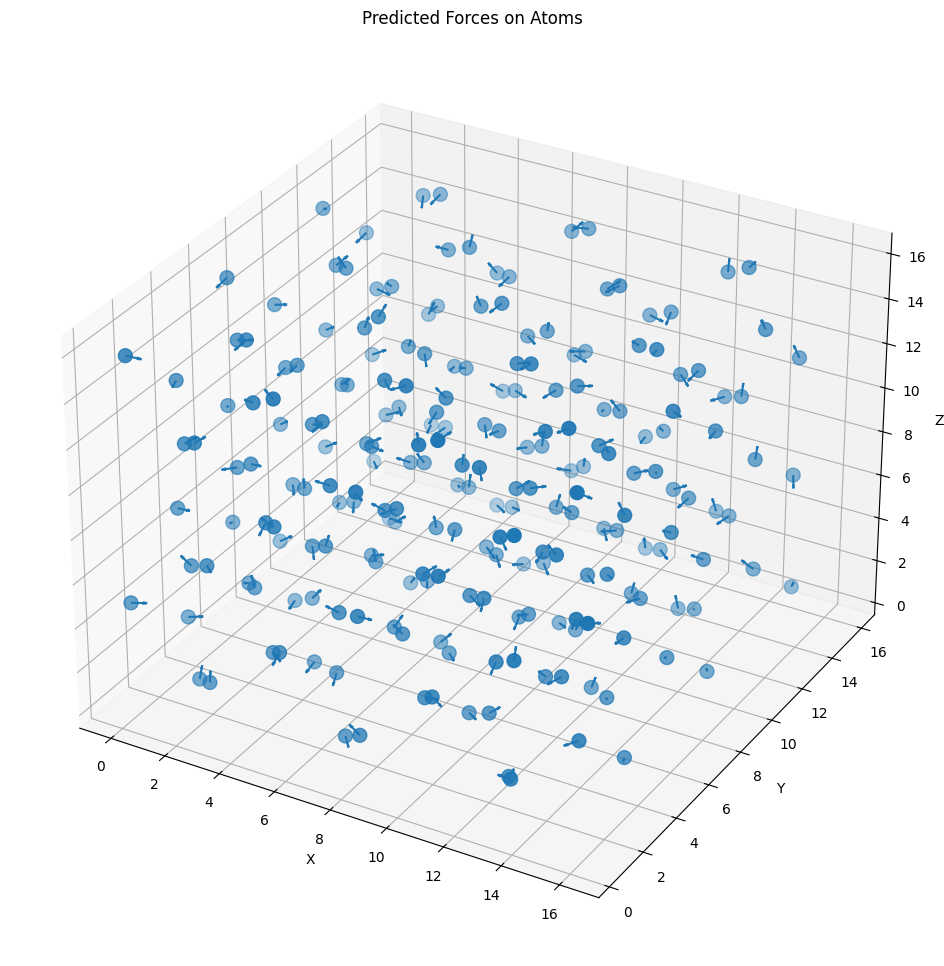

In [ ]:
positions = x["positions"].detach().numpy()
forces_np = forces.detach().numpy()

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection="3d")

# Plot atoms
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], s=100)

# Plot forces as vectors
ax.quiver(
    positions[:, 0],
    positions[:, 1],
    positions[:, 2],
    forces_np[:, 0],
    forces_np[:, 1],
    forces_np[:, 2],
    length=0.5,
    normalize=True,
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Predicted Forces on Atoms")
plt.show()